In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import wordcloud

In [2]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\syedm\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


# load the data


In [3]:
netflix_df = pd.read_csv(r"C:\Users\syedm\OneDrive\Desktop\nnnnn\netflix_titles (2).csv")
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Get a concise summary of the dataframe

In [4]:
# Get a concise summary of the dataframe
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB



Insights:
- We have 8807 entities. Any column which contains less than 8807 entities contains missing values [director, cast, country, date_added, rating, duration].


- Data Type Inconsitency in date_added column. Ideally, it should be of datatime type but currently it is of object type.

- Number of features = 12

Data Cleaning and Transformation


Exact count of the missing values

In [5]:
netflix_df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Handle the "director' and 'cAst'

In [6]:
# 1.Handles missing values in 'director' and 'cast' .
# since these are text fields and many are missing , we'll them with 'unknown'
netflix_df['director'] = netflix_df['director'].fillna('unknnown')
netflix_df['cast'] = netflix_df['cast'].fillna('unknown')

In [7]:
netflix_df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

 # Handle the 'country' column

In [8]:
# 2.Handle missing 'country'
# We'll fill the with the mode, which is the most commom country.
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [9]:
netflix_df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

# Handle 'date_added','rating' and 'duration'

In [10]:
 # 3. Drop the few rows with missing 'date added' and 'rating'

#Since the number is small (less than 0.2% of data), dropping them is a safe option.

netflix_df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

In [11]:
netflix_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# Data type consistency in the 'date_added' column

In [12]:
# 4.convert 'date_added'to datetime objects
# use format='mixed' to handle potential variation in date formats
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], format='mixed', dayfirst=False)

In [13]:
netflix_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64



# Feature engineering

In [14]:
# 5. Create new features for year and month added

netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df ['date_added'].dt.month

# Final confirmation  after handling missing values and data type inconsistency

In [15]:
# Verify our cleaning and transformation

print("Missing values after cleaning:")

print(netflix_df.isnull().sum())

print("\nData types after transformation:")

print(netflix_df.dtypes)



Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


# Exploratory data analysis

# univariate analysis => only one variable /feature at a time

distribution of content type

In [16]:
type_counts = netflix_df['type'].value_counts
print(type_counts)

<bound method IndexOpsMixin.value_counts of 0         Movie
1       TV Show
2       TV Show
3       TV Show
4       TV Show
         ...   
8802      Movie
8803    TV Show
8804      Movie
8805      Movie
8806      Movie
Name: type, Length: 8790, dtype: object>


# Pie chart

Insights:The netflix library is highly dominated by movies,which make up roughly 70% of the  content in this specific dataset

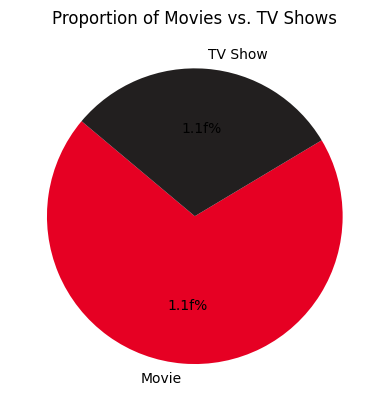

In [17]:
# Make sure type_counts is actually a Series
type_counts = netflix_df['type'].value_counts()

plt.pie(type_counts, 
        labels=type_counts.index, 
        autopct='1.1f%%', 
        startangle=140, 
        colors=['#e60023', '#221f1f'])

plt.title('Proportion of Movies vs. TV Shows')
plt.ylabel('')
plt.show()

How has the content  added over the time?

In [18]:
# group data by year and content type
content_over_time = netflix_df.groupby(['year_added', 'type']).size().unstack().fillna(0)
print(content_over_time)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


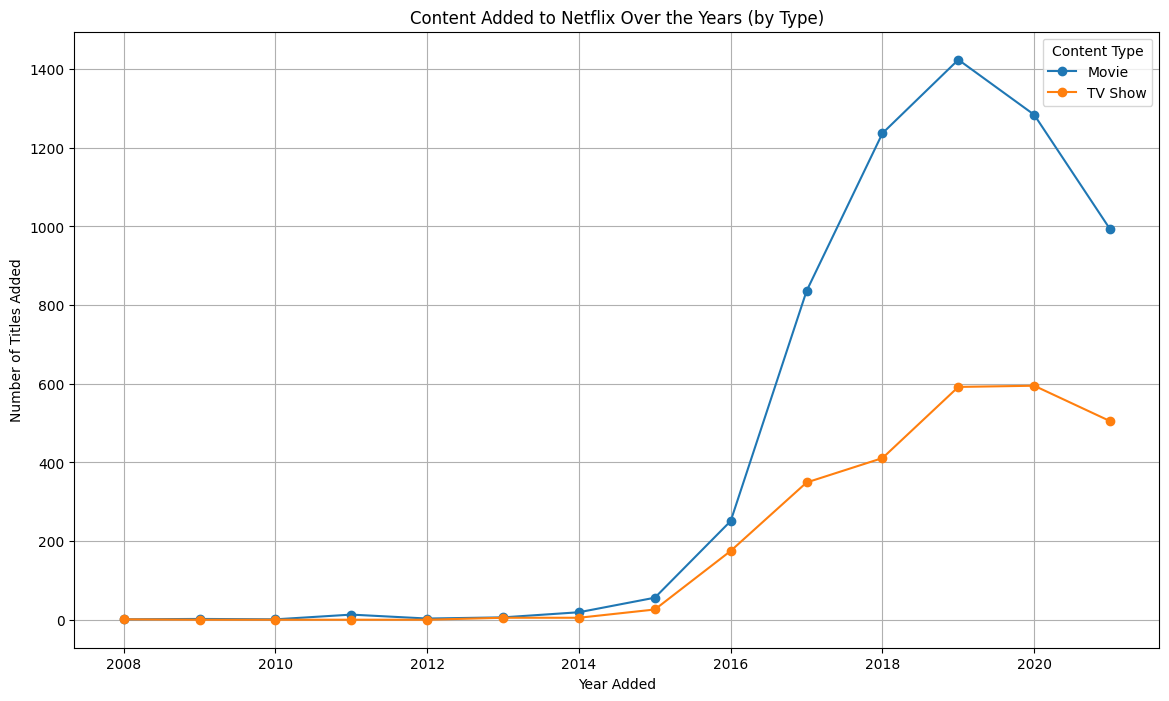

In [19]:
content_over_time.plot(kind='line', marker='o', figsize=(14,8))
plt.title('Content Added to Netflix Over the Years (by Type)')

plt.xlabel('Year Added')

plt.ylabel('Number of Titles Added')

plt.legend(title='Content Type')

plt.grid(True)

plt.show()

Insight: By separating movies and TV shows, we can clearly see that while both grew significantly from the year 2008 to 2020, the addition of movies accelerated more dramatically, especially in the year 2019. The growth in the TV shows has beernn more steady. There appears to be slight shutdown in content additions in the year 2020 and 2021, which could be due to the peak of COVID-19 at that time which might affects the productions or maybe the dataset could be incomplete for the latest years.

what are the most popular in genre?

In [20]:
# split the 'listed_in' column and explode it
genre = netflix_df.assign(genre=netflix_df['listed_in'].str.split(', ')).explode('genre')
genre

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Documentaries
1,s2,TV Show,Blood & Water,unknnown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,International TV Shows
1,s2,TV Show,Blood & Water,unknnown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Dramas
1,s2,TV Show,Blood & Water,unknnown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Children & Family Movies
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Comedies
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,Dramas
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,International Movies


# Most popular genres

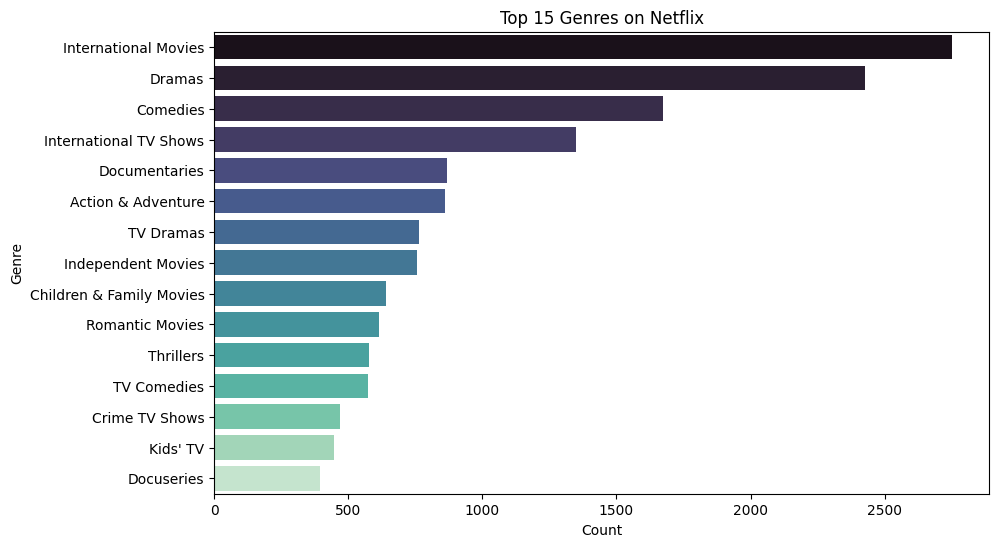

In [21]:
# Split genres and explode into separate rows
genres = netflix_df['listed_in'].str.split(', ').explode().to_frame(name='genres')

# Now this will work
top_genres_counts = genres['genres'].value_counts().reset_index()
top_genres_counts.columns = ['genres', 'count']

# Select top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

plt.figure(figsize=(10,6))
sns.barplot(y='genres', x='count', data=top_genres_counts_plot, palette='mako', hue='genres', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

Insights:international movies is the most common genre highlighting the netflix  global content stratagy.

# Distribution of content duration

In [22]:
# separate movies

movies_df = netflix_df[netflix_df['type'] == 'Movie'].copy()

movies_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016,3
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1


In [23]:

# tv shows
tv_shows_df = netflix_df[netflix_df['type'] == 'Tv_show'].copy()
tv_shows_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added


In [24]:
# clean and convert duration for movies 
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# # clean and convert duration for tv shows
tv_shows_df['seasons'] = tv_shows_df['duration'].str.replace(' seasons', '').str.replace(' seasons', '').astype(int)

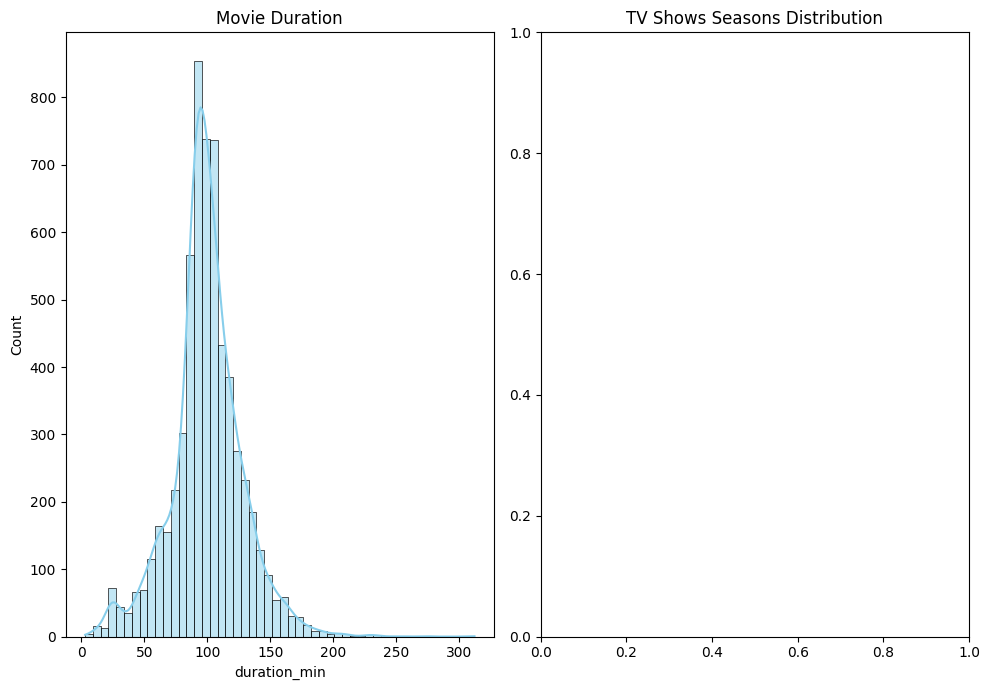

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 7))

# Movie Duration Distribution
sns.histplot(
    ax=axes[0],
    data=movies_df,
    x='duration_min',
    bins=50,
    kde=True,
    color='skyblue'
)
axes[0].set_title('Movie Duration')

# TV Shows Seasons Distribution
sns.countplot(
    ax=axes[1],
    x='duration',      # or 'seasons' if that column actually exists
    data=tv_shows_df,
    order=tv_shows_df['duration'].value_counts().index
)
axes[1].set_title('TV Shows Seasons Distribution')

plt.tight_layout()
plt.show()

Insights:
- The majority of the movies on Netflix are in the range between 80 and 120 minutes long, which is ideally the standard for any features films.

-The vast majority of the TV shows on Netflix are short-lived, with most having only 1 season. This could also reflect a strategy of producing many plots and only reviewing the most succesffulk ones, or a focus on limited series.

Where does the content come from?



In [26]:

# Handle the multi-country listings similar to genres

countries = netflix_df.assign(country=netflix_df['country'].str.split(', ')).explode('country')

#Get the top 15 countries and their counts

top_countries_counts = countries['country'].value_counts().reset_index()

top_countries_counts.columns = ['country', 'count'] # Rename columns for clarity
print(top_countries_counts)

            country  count
0     United States   4509
1             India   1046
2    United Kingdom    803
3            Canada    445
4            France    393
..              ...    ...
122           Sudan      1
123          Panama      1
124          Uganda      1
125    East Germany      1
126      Montenegro      1

[127 rows x 2 columns]


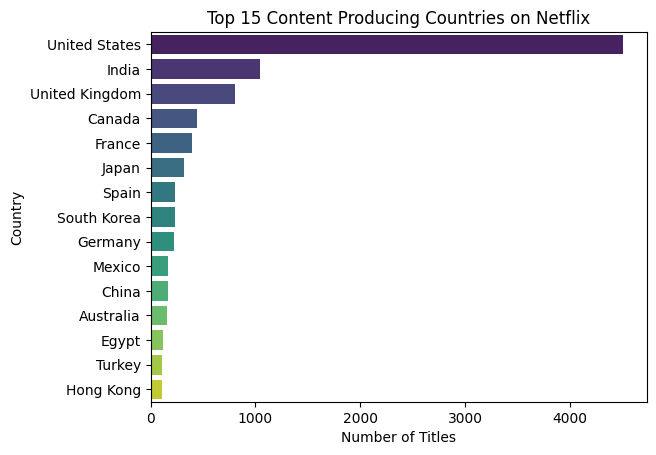

In [27]:
# Select only the top 15 for plotting

top_countries_counts_plot = top_countries_counts.head(15)

sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)

plt.title('Top 15 Content Producing Countries on Netflix')

plt.xlabel('Number of Titles')

plt.ylabel('Country')

plt.show()

Insights: The us is by far the largest producer of the content available on netflix followed by india which somehow explains that why so many of the actors from india. 

# Maturity rating of the content

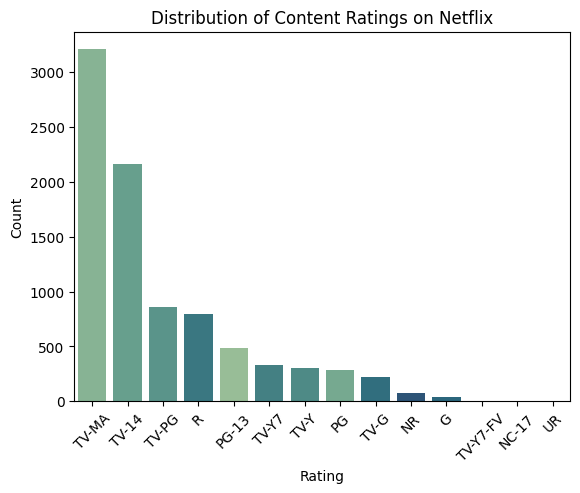

In [28]:
sns.countplot(x='rating', 
              data=netflix_df, 
              order=netflix_df['rating'].value_counts().index, 
              palette='crest', 
              hue='rating', 
              legend=False)

plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Insight: A large portion of the Netflix content aimed at mature audiences, with TV-MA (Mature Audience) and TV-14 (Parents Strongly Cautioned) being the two most common ratings.

# Feature engineering

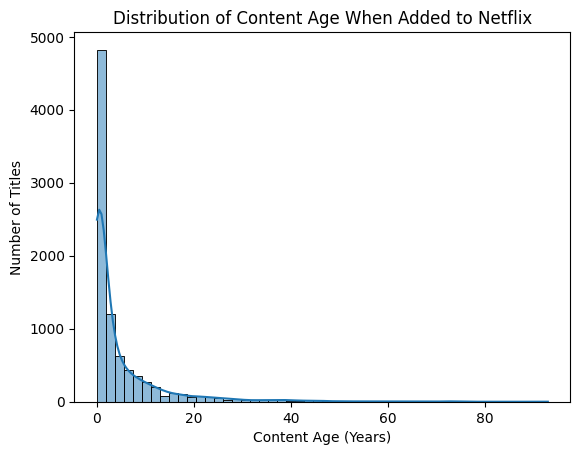

In [29]:
# create the 'age_on_netflix' feature
netflix_df['age_on_netflix'] = netflix_df['year_added'] - netflix_df['release_year']

# Filter out any potential errors where added year is before release_year
content_age = netflix_df[netflix_df['age_on_netflix'] >= 0]

sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)

plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

Insight: The large spike at e indicates that the significant amount of content is being added in the same year, which is the characterstic of the "Netflix Originals. However, there is a very long tail, showing that Netflix also heavily invests in acquiring licensed content that can be decaded old, building a deep library of classic files and TV shows.

# Multivariate analysis

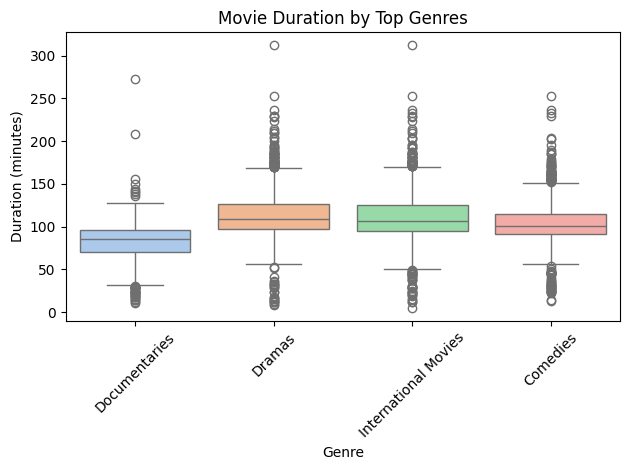

In [30]:
# Rebuild genres so it keeps type + duration + listed_in
genres = netflix_df[['type', 'listed_in', 'duration']].copy()
genres = genres.assign(genres=genres['listed_in'].str.split(', ')).explode('genres')

# Now analyze movie duration across different top genres
top_genres = genres['genres'].value_counts().index[:5]

genres_movies = genres[(genres['type'] == 'Movie') & (genres['genres'].isin(top_genres))].copy()

# Clean duration: '90 min' -> 90
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

sns.boxplot(data=genres_movies, x='genres', y='duration_min', palette='pastel', hue='genres', legend=False)

plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Dramas & Internaiton Movies have more outliers and reflects the diverse filmmaking styles around the world.

# Word cloud from the content description

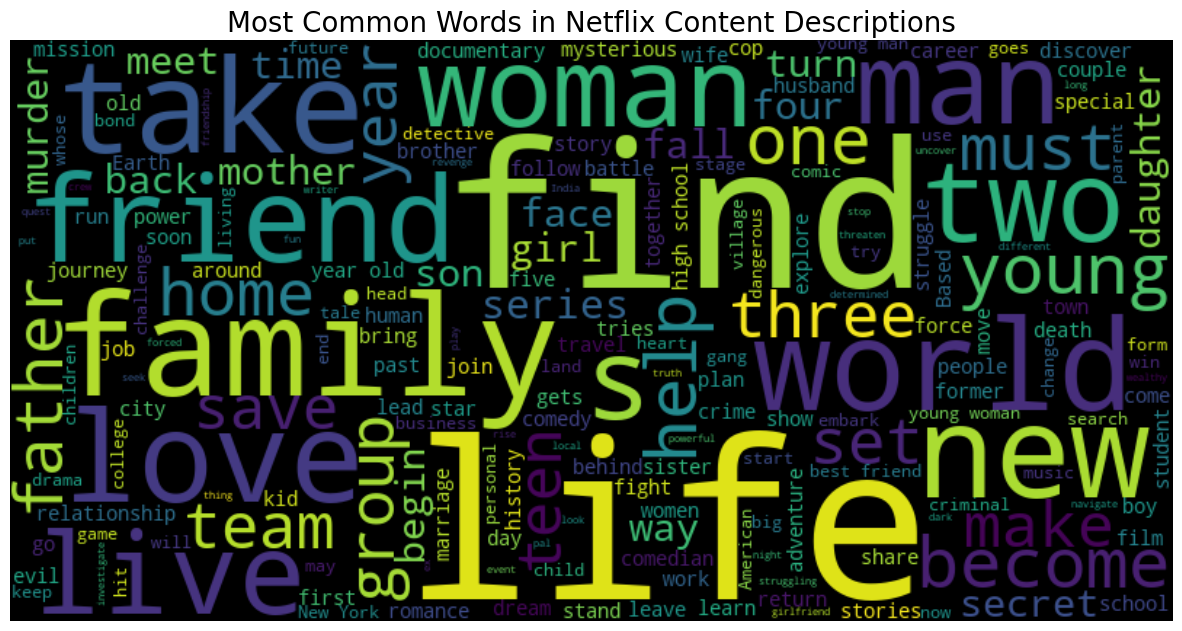

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all descriptions into a single string
text = ' '.join(netflix_df['description'].dropna())

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

Insight: The word cloud highlights common themes and subjects. Words like "life," "family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys. Action-oriented words like "find," "secret," and "new" also appear frequently.

This in-depth EDA of the Netflix dataset has revealed several key characteristics and strategies of the platform's content library.

Key Findings:

1. Content Strategy: Netflix's library is movie-heavy (~70%), and the platform aggressively added content between 2016-2019. Their strategy involves a mix of brand new originals (added the same year they are released) and a deep library of licensed older content.

2. Global Dominance: While the US is the top content producer, the platform is heavily international, with India being a massive contributor. This is reflected in the top genres ("International Movies") and most frequent actors.

3. Target Audience: The content library is skewed towards mature audiences, with TV-MA and TV-14 being the most common ratings.

4. Content Format & Genre: Dramas and Comedies are universally popular genres. Most movies stick to a standard 90-120 minute runtime, while the vast majority of TV shows only last for a single season, suggesti high-risk, high-reward approach to series production.

4. Common Themes: Descriptions of content frequently revolve around universal themes of life, far discovery.

Limitations: This dataset is a snapshot in time and lacks viewership data. Therefore, our analysis of content, not its demand or popularity. Nonetheless, this EDA provides a strong, multi-faceted of the composition and evolution of the Netflix library.